In [1]:
# GPU kontrolü
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    print("⚠️ GPU yok! Runtime → Change runtime type → T4 GPU")
    device = torch.device('cpu')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
from getpass import getpass

github_token = getpass('GitHub token: ')
github_user = 'iremcesur'
repo_name = 'CENG467_Midterm_310201051'

!git clone https://{github_token}@github.com/{github_user}/{repo_name}.git
%cd {repo_name}

!git config user.email "iremcesur310201051@gmail.com"
!git config user.name "iremcesur"
!git config pull.rebase false

GitHub token: ··········
Cloning into 'CENG467_Midterm_310201051'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 29 (delta 7), reused 17 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 1.12 MiB | 10.23 MiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/CENG467_Midterm_310201051


In [3]:
import random
import numpy as np
import torch
import os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Deterministic algoritmaları zorla (yavaşlatır ama tekrar üretilebilirlik için)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"✓ All seeds set to {SEED}")
print(f"✓ Device: {device}")

✓ All seeds set to 42
✓ Device: cuda


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
from collections import Counter
from tqdm.notebook import tqdm

print("✓ All imports successful")

✓ All imports successful


In [5]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split

print("Loading IMDb dataset...")
dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# AYNI SEED ile aynı subset oluşur
train_subset, val_subset = train_test_split(
    train_df.sample(n=6000, random_state=SEED, replace=False),
    test_size=1000,
    stratify=train_df.sample(n=6000, random_state=SEED, replace=False)['label'],
    random_state=SEED
)
test_subset = test_df.sample(n=2000, random_state=SEED, replace=False)

train_subset = train_subset.reset_index(drop=True)
val_subset = val_subset.reset_index(drop=True)
test_subset = test_subset.reset_index(drop=True)

print(f"\nSubset sizes (verify same as TF-IDF notebook):")
print(f"  Train: {len(train_subset)} | {train_subset['label'].value_counts().to_dict()}")
print(f"  Val:   {len(val_subset)}  | {val_subset['label'].value_counts().to_dict()}")
print(f"  Test:  {len(test_subset)} | {test_subset['label'].value_counts().to_dict()}")

# Diske kaydet (BERT notebook'u da kullanacak)
os.makedirs('data/processed', exist_ok=True)
train_subset.to_csv('data/processed/imdb_train.csv', index=False)
val_subset.to_csv('data/processed/imdb_val.csv', index=False)
test_subset.to_csv('data/processed/imdb_test.csv', index=False)
print("\n✓ Subsets saved")

Loading IMDb dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


Subset sizes (verify same as TF-IDF notebook):
  Train: 5000 | {1: 2507, 0: 2493}
  Val:   1000  | {1: 501, 0: 499}
  Test:  2000 | {0: 1040, 1: 960}

✓ Subsets saved


In [6]:
# GloVe 100d embeddings'i indir (~340 MB sıkıştırılmış)
import urllib.request
import zipfile

glove_url = "https://nlp.stanford.edu/data/glove.6B.zip"
glove_zip = "glove.6B.zip"
glove_file = "glove.6B.100d.txt"

if not os.path.exists(glove_file):
    print("Downloading GloVe (this may take 1-2 minutes)...")
    urllib.request.urlretrieve(glove_url, glove_zip)
    print("Extracting...")
    with zipfile.ZipFile(glove_zip, 'r') as z:
        z.extract(glove_file)
    os.remove(glove_zip)
    print("✓ GloVe ready")
else:
    print("✓ GloVe already downloaded")

!ls -lh {glove_file}

Extracting...
✓ GloVe ready
-rw-r--r-- 1 root root 332M May  5 19:43 glove.6B.100d.txt


In [7]:
import re

def simple_tokenize(text):
    """Basit tokenizer: lowercase, HTML temizle, kelimelere ayır."""
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)  # IMDb'de <br /> tagları var
    text = re.sub(r"[^a-z0-9\s']", ' ', text)  # Sadece harf, rakam, kesme işareti
    tokens = text.split()
    return tokens

# Test
sample = train_subset['text'].iloc[0]
print(f"Original (first 200 chars): {sample[:200]}")
print(f"\nTokens (first 20): {simple_tokenize(sample)[:20]}")

Original (first 200 chars): Dripping with symbolism and filled with marvelous cinematography, Extase is so much more than the erotic drama we've all come to expect. This is almost a silent film, with what dialogue there is in Ge

Tokens (first 20): ['dripping', 'with', 'symbolism', 'and', 'filled', 'with', 'marvelous', 'cinematography', 'extase', 'is', 'so', 'much', 'more', 'than', 'the', 'erotic', 'drama', "we've", 'all', 'come']


In [8]:
# Tüm train texts'i tokenize et
print("Tokenizing training set...")
train_tokens = [simple_tokenize(text) for text in tqdm(train_subset['text'])]

# Word frequency
word_counter = Counter()
for tokens in train_tokens:
    word_counter.update(tokens)

print(f"\nTotal unique words: {len(word_counter)}")
print(f"Most common 10: {word_counter.most_common(10)}")

# Vocabulary kur (en sık 30K kelime)
VOCAB_SIZE = 30000
PAD_IDX = 0  # Padding token
UNK_IDX = 1  # Unknown token

# word -> index mapping
word2idx = {'<pad>': PAD_IDX, '<unk>': UNK_IDX}
for word, _ in word_counter.most_common(VOCAB_SIZE - 2):
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

print(f"\nVocab size: {len(word2idx)}")
print(f"Sample mapping: 'good' -> {word2idx.get('good', UNK_IDX)}")
print(f"Sample mapping: 'movie' -> {word2idx.get('movie', UNK_IDX)}")

Tokenizing training set...


  0%|          | 0/5000 [00:00<?, ?it/s]


Total unique words: 42597
Most common 10: [('the', 67400), ('and', 33094), ('a', 32535), ('of', 29427), ('to', 27402), ('is', 21571), ('in', 18770), ('it', 15849), ('i', 15310), ('this', 15228)]

Vocab size: 30000
Sample mapping: 'good' -> 49
Sample mapping: 'movie' -> 18


In [9]:
EMBEDDING_DIM = 100

print(f"Loading GloVe vectors and building embedding matrix...")

# Embedding matrix init: vocab_size x embed_dim
embedding_matrix = np.zeros((len(word2idx), EMBEDDING_DIM), dtype=np.float32)

# GloVe dosyasını oku
glove_count = 0
with open('glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in tqdm(f, total=400000):  # GloVe 6B has ~400K words
        parts = line.split()
        word = parts[0]
        if word in word2idx:
            vector = np.array(parts[1:], dtype=np.float32)
            embedding_matrix[word2idx[word]] = vector
            glove_count += 1

# Coverage istatistiği
coverage = glove_count / (len(word2idx) - 2) * 100  # -2: pad ve unk hariç
print(f"\n✓ Embedding matrix shape: {embedding_matrix.shape}")
print(f"✓ Words covered by GloVe: {glove_count} / {len(word2idx)-2} ({coverage:.1f}%)")
print(f"  Out-of-vocab words have zero vectors (will not learn since embeddings are frozen)")

Loading GloVe vectors and building embedding matrix...


  0%|          | 0/400000 [00:00<?, ?it/s]


✓ Embedding matrix shape: (30000, 100)
✓ Words covered by GloVe: 26463 / 29998 (88.2%)
  Out-of-vocab words have zero vectors (will not learn since embeddings are frozen)


In [10]:
class IMDbDataset(Dataset):
    """IMDb review'leri için PyTorch Dataset."""

    def __init__(self, texts, labels, word2idx, max_len=256):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len
        self.unk_idx = word2idx['<unk>']

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = simple_tokenize(self.texts[idx])
        # Token'ları index'e çevir, max_len'e kes
        ids = [self.word2idx.get(t, self.unk_idx) for t in tokens[:self.max_len]]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float)


def collate_fn(batch):
    """Batch içindeki sequence'leri pad et."""
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences])
    padded = pad_sequence(sequences, batch_first=True, padding_value=PAD_IDX)
    labels = torch.stack(labels)
    return padded, lengths, labels


# Dataset'leri oluştur
MAX_LEN = 256

train_ds = IMDbDataset(train_subset['text'].tolist(), train_subset['label'].tolist(),
                       word2idx, max_len=MAX_LEN)
val_ds = IMDbDataset(val_subset['text'].tolist(), val_subset['label'].tolist(),
                     word2idx, max_len=MAX_LEN)
test_ds = IMDbDataset(test_subset['text'].tolist(), test_subset['label'].tolist(),
                      word2idx, max_len=MAX_LEN)

# DataLoader'lar
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Sanity check
sample_batch = next(iter(train_loader))
print(f"Batch shape: {sample_batch[0].shape}")  # (batch, seq_len)
print(f"Sample lengths: {sample_batch[1][:5].tolist()}")
print(f"Sample labels: {sample_batch[2][:5].tolist()}")

Batch shape: torch.Size([64, 256])
Sample lengths: [256, 174, 65, 227, 125]
Sample labels: [1.0, 0.0, 1.0, 1.0, 0.0]


In [18]:
# Hücre 11'i olduğu gibi yeniden çalıştır
# (ama önce seed'i resetlemek için bunu en üste ekle veya ayrı hücrede çalıştır)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model = BiLSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=128,
    num_layers=1,
    dropout=0.5,
    freeze_embeddings=True
).to(device)

print(f"✓ Model reinitialized")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")

✓ Model reinitialized
Total params: 3,235,777


In [19]:
class BiLSTMClassifier(nn.Module):
    """Bidirectional LSTM with pre-trained GloVe embeddings."""

    def __init__(self, embedding_matrix, hidden_dim=128, num_layers=1,
                 dropout=0.5, freeze_embeddings=True):
        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        # Embedding layer (GloVe ile init)
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            freeze=freeze_embeddings,
            padding_idx=PAD_IDX
        )

        # BiLSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Classifier head
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # *2 because bidirectional

    def forward(self, x, lengths):
        # x: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)

        # Pack padded sequence (more efficient)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # BiLSTM
        packed_out, (h_n, c_n) = self.lstm(packed)
        output, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        # output: (batch, seq_len, hidden*2)

        # Mean pooling (sadece padding olmayan kısım üzerinden)
        mask = (x != PAD_IDX).float().unsqueeze(-1)  # (batch, seq_len, 1)
        output_masked = output * mask[:, :output.size(1), :]
        pooled = output_masked.sum(dim=1) / mask[:, :output.size(1), :].sum(dim=1).clamp(min=1)

        # Classifier
        pooled = self.dropout(pooled)
        logits = self.fc(pooled).squeeze(-1)  # (batch,)

        return logits


# Model oluştur
model = BiLSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=128,
    num_layers=1,
    dropout=0.5,
    freeze_embeddings=True
).to(device)

# Parametreleri say
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen (embeddings): {total_params - trainable_params:,}")
print(f"\nModel architecture:")
print(model)

Total parameters: 3,235,777
Trainable parameters: 235,777
Frozen (embeddings): 3,000,000

Model architecture:
BiLSTMClassifier(
  (embedding): Embedding(30000, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


In [13]:
def train_epoch(model, loader, optimizer, criterion, device):
    """Bir epoch eğitim."""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x, lengths, y in tqdm(loader, desc='Train', leave=False):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = criterion(logits, y)
        loss.backward()

        # Gradient clipping (LSTM exploding gradient'ten korur)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = (torch.sigmoid(logits) > 0.5).long().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.cpu().numpy().astype(int))

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def evaluate(model, loader, criterion, device):
    """Validation/test evaluation."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for x, lengths, y in loader:
            x, y = x.to(device), y.to(device)

            logits = model(x, lengths)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(y.cpu().numpy().astype(int))

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, f1, all_preds, all_labels, all_probs


print("✓ Training functions defined")

✓ Training functions defined


In [20]:
# Hyperparameters
LEARNING_RATE = 1e-3
NUM_EPOCHS = 15
PATIENCE = 4  # Early stopping: 3 epoch boyunca val improvement yoksa dur

# Optimizer ve loss
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

# Tracking
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_f1 = 0
best_epoch = 0
patience_counter = 0
best_model_state = None

print(f"Starting training: {NUM_EPOCHS} epochs max, early stopping patience={PATIENCE}")
print(f"Device: {device}, Batch size: {BATCH_SIZE}, LR: {LEARNING_RATE}")
print("=" * 70)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

    # Validate
    val_loss, val_acc, val_f1, _, _, _ = evaluate(model, val_loader, criterion, device)

    epoch_time = time.time() - epoch_start

    # Log
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} | "
          f"Time: {epoch_time:.1f}s")

    # Early stopping logic
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  → New best val F1: {best_val_f1:.4f} (saved)")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏸ Early stopping triggered at epoch {epoch} "
                  f"(no improvement for {PATIENCE} epochs)")
            break

total_time = time.time() - start_time
print("=" * 70)
print(f"Training complete in {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"Best validation F1: {best_val_f1:.4f} at epoch {best_epoch}")

# En iyi modeli yükle
model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
print(f"✓ Best model restored")

Starting training: 15 epochs max, early stopping patience=4
Device: cuda, Batch size: 64, LR: 0.001


Train:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch  1/15 | Train Loss: 0.6540 Acc: 0.6076 | Val Loss: 0.6190 Acc: 0.6590 F1: 0.6475 | Time: 4.7s
  → New best val F1: 0.6475 (saved)


Train:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch  2/15 | Train Loss: 0.5581 Acc: 0.7230 | Val Loss: 0.5232 Acc: 0.7400 F1: 0.7399 | Time: 4.0s
  → New best val F1: 0.7399 (saved)


...

Epoch 13/15 | Train Loss: 0.2977 Acc: 0.8728 | Val Loss: 0.3636 Acc: 0.8510 F1: 0.8509 | Time: 3.6s
  → New best val F1: 0.8509 (saved)


Train:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 0.2813 Acc: 0.8796 | Val Loss: 0.4077 Acc: 0.8220 F1: 0.8197 | Time: 3.6s


Train:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 0.2688 Acc: 0.8932 | Val Loss: 0.3725 Acc: 0.8370 F1: 0.8363 | Time: 3.8s
Training complete in 56.9s (0.9 min)
Best validation F1: 0.8509 at epoch 13
✓ Best model restored


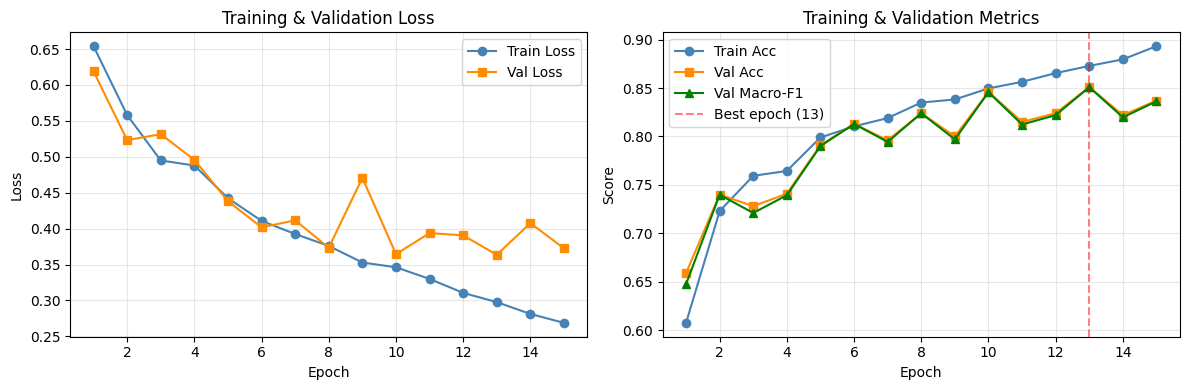

✓ Training curves saved


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='steelblue')
axes[0].plot(epochs, history['val_loss'], 's-', label='Val Loss', color='darkorange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_acc'], 'o-', label='Train Acc', color='steelblue')
axes[1].plot(epochs, history['val_acc'], 's-', label='Val Acc', color='darkorange')
axes[1].plot(epochs, history['val_f1'], '^-', label='Val Macro-F1', color='green')
axes[1].axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Training & Validation Metrics')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q1_classification/results/bilstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training curves saved")

In [22]:
print("=" * 60)
print("BiLSTM — FINAL TEST EVALUATION")
print("=" * 60)

test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = evaluate(
    model, test_loader, criterion, device
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")
print()
print("Detailed Classification Report:")
print(classification_report(test_labels, test_preds,
                            target_names=['Negative', 'Positive'],
                            digits=4))

BiLSTM — FINAL TEST EVALUATION

Test Loss: 0.3518
Test Accuracy: 0.8535
Test Macro-F1: 0.8531

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative     0.8507    0.8712    0.8608      1040
    Positive     0.8567    0.8344    0.8454       960

    accuracy                         0.8535      2000
   macro avg     0.8537    0.8528    0.8531      2000
weighted avg     0.8536    0.8535    0.8534      2000



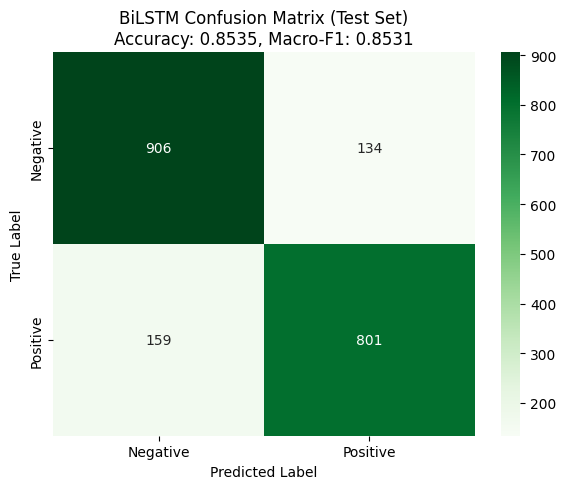


Breakdown:
  TN: 906, FP: 134, FN: 159, TP: 801


In [23]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title(f'BiLSTM Confusion Matrix (Test Set)\nAccuracy: {test_acc:.4f}, Macro-F1: {test_f1:.4f}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()

plt.savefig('q1_classification/results/bilstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBreakdown:")
print(f"  TN: {cm[0,0]}, FP: {cm[0,1]}, FN: {cm[1,0]}, TP: {cm[1,1]}")

In [24]:
# Test set'e BiLSTM predictions ekle
test_subset_with_preds = test_subset.copy()
test_subset_with_preds['bilstm_pred'] = test_preds
test_subset_with_preds['bilstm_correct'] = (np.array(test_preds) == np.array(test_labels))
test_subset_with_preds['bilstm_pos_prob'] = test_probs

# Tahminli test setini kaydet
test_subset_with_preds.to_csv(
    'q1_classification/results/test_predictions_bilstm.csv', index=False
)
print(f"✓ Test predictions saved")

# Yanlış tahminler özeti
n_wrong = (~test_subset_with_preds['bilstm_correct']).sum()
fp = ((test_subset_with_preds['label']==0) & (test_subset_with_preds['bilstm_pred']==1)).sum()
fn = ((test_subset_with_preds['label']==1) & (test_subset_with_preds['bilstm_pred']==0)).sum()
print(f"\nMisclassified: {n_wrong}/{len(test_subset)} ({n_wrong/len(test_subset)*100:.1f}%)")
print(f"  FP (neg→pos): {fp}")
print(f"  FN (pos→neg): {fn}")

✓ Test predictions saved

Misclassified: 293/2000 (14.6%)
  FP (neg→pos): 134
  FN (pos→neg): 159


In [25]:
results = {
    'model': 'BiLSTM + GloVe (frozen)',
    'config': {
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': 128,
        'num_layers': 1,
        'dropout': 0.5,
        'freeze_embeddings': True,
        'max_seq_length': MAX_LEN,
        'vocab_size': len(word2idx),
        'glove_coverage': float(coverage),
        'pooling': 'mean (masked)',
    },
    'training': {
        'optimizer': 'Adam',
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'max_epochs': NUM_EPOCHS,
        'early_stopping_patience': PATIENCE,
        'best_epoch': best_epoch,
        'epochs_trained': len(history['train_loss']),
        'training_time_seconds': total_time,
    },
    'subset_sizes': {'train': 5000, 'val': 1000, 'test': 2000},
    'random_seed': SEED,
    'history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'train_acc': [float(x) for x in history['train_acc']],
        'val_loss': [float(x) for x in history['val_loss']],
        'val_acc': [float(x) for x in history['val_acc']],
        'val_f1': [float(x) for x in history['val_f1']],
    },
    'val_metrics': {'best_f1': float(best_val_f1), 'best_epoch': best_epoch},
    'test_metrics': {
        'accuracy': float(test_acc),
        'macro_f1': float(test_f1),
        'loss': float(test_loss),
        'confusion_matrix': cm.tolist(),
    }
}

with open('q1_classification/results/bilstm_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✓ Results saved to q1_classification/results/bilstm_results.json")

✓ Results saved to q1_classification/results/bilstm_results.json


In [26]:
# .gitignore'a glove dosyasını ekle (commit etmeyelim, çok büyük)
gitignore_addition = "\n# GloVe embeddings (downloaded separately)\nglove.6B.100d.txt\nglove.6B.zip\n"

with open('.gitignore', 'a') as f:
    f.write(gitignore_addition)

!git pull origin main --no-edit
!git add q1_classification/ .gitignore
!git commit -m "Q1: BiLSTM+GloVe (test acc, f1 will fill in)"
!git push origin main

From https://github.com/iremcesur/CENG467_Midterm_310201051
 * branch            main       -> FETCH_HEAD
Already up to date.
[main 5a3eeaf] Q1: BiLSTM+GloVe (test acc, f1 will fill in)
 5 files changed, 2141 insertions(+)
 create mode 100644 q1_classification/results/bilstm_confusion_matrix.png
 create mode 100644 q1_classification/results/bilstm_results.json
 create mode 100644 q1_classification/results/bilstm_training_curves.png
 create mode 100644 q1_classification/results/test_predictions_bilstm.csv
Enumerating objects: 13, done.
Counting objects: 100% (13/13), done.
Delta compression using up to 2 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 1.16 MiB | 1.90 MiB/s, done.
Total 9 (delta 2), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (2/2), completed with 2 local objects.
To https://github.com/iremcesur/CENG467_Midterm_310201051.git
   0368208..5a3eeaf  main -> main
